In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── IMPORTS ──────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import joblib
import scipy.sparse as sp
warnings.filterwarnings("ignore", category=UserWarning)

import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 130

from scipy.stats import spearmanr
from matplotlib.patches import Patch

In [3]:
# ── CONFIGURATION ────────────────────────────────────────────
SEED       = 42
DATA_PATH  = "/content/drive/MyDrive/FakeReviewProject/"
A1_PATH    = DATA_PATH + "experiment_a1/models/"
B1_PATH    = DATA_PATH + "experiment_b1/models/"
B2_PATH    = DATA_PATH + "experiment_b2/models/"
SHAP_A1    = DATA_PATH + "experiment_a1/shap/"
SHAP_B1    = DATA_PATH + "experiment_b1/shap/"
SHAP_B2    = DATA_PATH + "experiment_b2/shap/"
SHAP_CROSS = DATA_PATH + "shap_comparison/"

for p in [SHAP_A1, SHAP_B1, SHAP_B2, SHAP_CROSS]:
    os.makedirs(p, exist_ok=True)

np.random.seed(SEED)

META_COLS = ["rating", "review_length", "extreme_rating",
             "review_month", "review_dayofweek", "is_weekend"]

SHAP_N = 500   # background sample size per experiment

# ============================================================
# 1. LOAD DATASETS
# ============================================================

In [4]:
print("=" * 60)
print("1. LOADING AND FILTERING DATASETS")
print("=" * 60)

df_full = pd.read_csv(DATA_PATH + "yelp_nyc_processed_v2.csv",
                      parse_dates=["review_date"])
df_full = df_full.reset_index(drop=True)
print(f"Unfiltered: {df_full.shape}")

df_filt = df_full.copy()
while True:
    n_before = len(df_filt)
    rc = df_filt["reviewer_id"].value_counts()
    df_filt = df_filt[df_filt["reviewer_id"].isin(rc[rc > 3].index)]
    pc = df_filt["product_id"].value_counts()
    df_filt = df_filt[df_filt["product_id"].isin(pc[pc > 3].index)]
    if len(df_filt) == n_before:
        break
df_filt = df_filt.reset_index(drop=True)
print(f"Filtered   : {df_filt.shape}")

1. LOADING AND FILTERING DATASETS
Unfiltered: (359052, 13)
Filtered   : (172389, 13)


# ============================================================
# 2. LOAD SPLIT INDICES
# ============================================================

In [6]:
print("\n" + "=" * 60)
print("2. LOADING SPLIT INDICES")
print("=" * 60)

a1_idx_val = np.load(A1_PATH + "idx_val.npy")
b1_idx_val = np.load(B1_PATH + "idx_val.npy")

# B2 uses SAME split as B1
b2_idx_val = b1_idx_val.copy()

# Verify
assert np.array_equal(b1_idx_val, b2_idx_val)
print("B1 and B2 val indices verified identical")

y_full = df_full["label"].values
y_filt = df_filt["label"].values

y_a1_val = y_full[a1_idx_val]
y_b1_val = y_filt[b1_idx_val]
y_b2_val = y_filt[b2_idx_val]

print(f"\nA1 val: {len(y_a1_val):,} | Fake: {y_a1_val.sum():,} ({y_a1_val.mean()*100:.1f}%)")
print(f"B1 val: {len(y_b1_val):,} | Fake: {y_b1_val.sum():,} ({y_b1_val.mean()*100:.1f}%)")
print(f"B2 val: {len(y_b2_val):,} | Fake: {y_b2_val.sum():,} ({y_b2_val.mean()*100:.1f}%)")


2. LOADING SPLIT INDICES
B1 and B2 val indices verified identical

A1 val: 53,858 | Fake: 5,533 (10.3%)
B1 val: 25,858 | Fake: 735 (2.8%)
B2 val: 25,858 | Fake: 735 (2.8%)


# ============================================================
# 4. LOAD MODELS
# ============================================================

In [7]:
print("\n" + "=" * 60)
print("3. BUILDING VALIDATION FEATURE MATRICES")
print("=" * 60)

# ── A1 ────────────────────────────────────────────────────────
a1_tfidf_val  = sp.load_npz(A1_PATH + "X_tfidf_val.npz")
a1_meta_scaler = joblib.load(A1_PATH + "meta_scaler.pkl")
a1_meta_val   = a1_meta_scaler.transform(
    df_full.iloc[a1_idx_val][META_COLS].values.astype(float))
X_a1_val = sp.hstack(
    [a1_tfidf_val, sp.csr_matrix(a1_meta_val)], format="csr"
)
a1_feature_names = joblib.load(A1_PATH + "feature_names.pkl")
a1_N_TFIDF = a1_tfidf_val.shape[1]
a1_N_META  = len(META_COLS)

assert X_a1_val.shape[1] == len(a1_feature_names), \
    f"A1 alignment error: {X_a1_val.shape[1]} vs {len(a1_feature_names)}"
print(f"A1 val matrix: {X_a1_val.shape} ✓")

# ── B1 ────────────────────────────────────────────────────────
b1_tfidf_val  = sp.load_npz(B1_PATH + "X_tfidf_val.npz")
b1_meta_scaler = joblib.load(B1_PATH + "meta_scaler.pkl")
b1_meta_val   = b1_meta_scaler.transform(
    df_filt.iloc[b1_idx_val][META_COLS].values.astype(float))
X_b1_val = sp.hstack(
    [b1_tfidf_val, sp.csr_matrix(b1_meta_val)], format="csr"
)
b1_feature_names = joblib.load(B1_PATH + "feature_names.pkl")
b1_N_TFIDF = b1_tfidf_val.shape[1]
b1_N_META  = len(META_COLS)

assert X_b1_val.shape[1] == len(b1_feature_names), \
    f"B1 alignment error: {X_b1_val.shape[1]} vs {len(b1_feature_names)}"
print(f"B1 val matrix: {X_b1_val.shape} ✓")

# ── B2 ────────────────────────────────────────────────────────
b2_tfidf_val  = b1_tfidf_val   # same vocab, same split
b2_meta_scaler = joblib.load(B2_PATH + "meta_scaler.pkl")
b2_meta_val   = b2_meta_scaler.transform(
    df_filt.iloc[b2_idx_val][META_COLS].values.astype(float))

behav_df     = joblib.load(B2_PATH + "behavioral_features.pkl")
behav_scaler = joblib.load(B2_PATH + "behav_scaler.pkl")
behav_cols   = list(behav_df.columns)
behav_val    = behav_scaler.transform(
    behav_df.iloc[b2_idx_val].values.astype(float))

X_b2_val = sp.hstack([
    b2_tfidf_val,
    sp.csr_matrix(b2_meta_val),
    sp.csr_matrix(behav_val),
], format="csr")

b2_feature_names = joblib.load(B2_PATH + "feature_names.pkl")
b2_N_TFIDF = b2_tfidf_val.shape[1]
b2_N_META  = len(META_COLS)
b2_N_BEHAV = len(behav_cols)
behav_start = b2_N_TFIDF + b2_N_META

assert X_b2_val.shape[1] == len(b2_feature_names), \
    f"B2 alignment error: {X_b2_val.shape[1]} vs {len(b2_feature_names)}"
print(f"B2 val matrix: {X_b2_val.shape} ✓")

print(f"\nFeature groups (B2):")
print(f"  TF-IDF     : {b2_N_TFIDF}")
print(f"  Metadata   : {b2_N_META}")
print(f"  Behavioral : {b2_N_BEHAV}")
print(f"  Total      : {X_b2_val.shape[1]}")

# ============================================================
# 4. LOAD MODELS
# ============================================================
print("\n" + "=" * 60)
print("4. LOADING MODELS")
print("=" * 60)

a1_lgbm = joblib.load(A1_PATH + "lightgbm.pkl")
b1_lgbm = joblib.load(B1_PATH + "lightgbm.pkl")
b2_lgbm = joblib.load(B2_PATH + "lightgbm.pkl")
b2_lr   = joblib.load(B2_PATH + "logistic_regression.pkl")
print("All models loaded")


3. BUILDING VALIDATION FEATURE MATRICES
A1 val matrix: (53858, 3006) ✓
B1 val matrix: (25858, 3006) ✓
B2 val matrix: (25858, 3061) ✓

Feature groups (B2):
  TF-IDF     : 3000
  Metadata   : 6
  Behavioral : 55
  Total      : 3061

4. LOADING MODELS
All models loaded


# ============================================================
# 5. STRATIFIED SHAP BACKGROUND SAMPLES
# ============================================================

In [8]:
print("\n" + "=" * 60)
print("5. PREPARING STRATIFIED SHAP BACKGROUND SAMPLES")
print("=" * 60)

def stratified_shap_sample(X_sparse, y, n=500, seed=42):
    """
    Stratified sample from validation set.
    Ensures minority class (fake) is well-represented.
    Returns:
      X_dense  : dense numpy array (n, n_features)
      X_sparse : sparse matrix (n, n_features) — for LinearExplainer
      y_sample : labels
      chosen   : indices into the validation set
    """
    rng      = np.random.RandomState(seed)
    fake_idx = np.where(y == 1)[0]
    gen_idx  = np.where(y == 0)[0]
    n_fake   = min(len(fake_idx), n // 2)
    n_gen    = n - n_fake
    chosen   = np.concatenate([
        rng.choice(fake_idx, size=n_fake, replace=False),
        rng.choice(gen_idx,  size=n_gen,  replace=False),
    ])
    rng.shuffle(chosen)
    X_sp     = X_sparse[chosen]
    X_dn     = np.array(X_sp.todense())
    return X_dn, X_sp, y[chosen], chosen

X_a1_shap, X_a1_shap_sp, y_a1_shap, _ = stratified_shap_sample(
    X_a1_val, y_a1_val, n=SHAP_N)
X_b1_shap, X_b1_shap_sp, y_b1_shap, _ = stratified_shap_sample(
    X_b1_val, y_b1_val, n=SHAP_N)
X_b2_shap, X_b2_shap_sp, y_b2_shap, _ = stratified_shap_sample(
    X_b2_val, y_b2_val, n=SHAP_N)

for label, X_s, y_s in [("A1", X_a1_shap, y_a1_shap),
                          ("B1", X_b1_shap, y_b1_shap),
                          ("B2", X_b2_shap, y_b2_shap)]:
    print(f"  {label}: {X_s.shape} | "
          f"Fake: {y_s.sum()} ({y_s.mean()*100:.1f}%)")


5. PREPARING STRATIFIED SHAP BACKGROUND SAMPLES
  A1: (500, 3006) | Fake: 250 (50.0%)
  B1: (500, 3006) | Fake: 250 (50.0%)
  B2: (500, 3061) | Fake: 250 (50.0%)


# ============================================================
# 6. COMPUTE SHAP VALUES
# ============================================================

In [15]:
print("\n" + "=" * 60)
print("6. COMPUTING SHAP VALUES")
print("=" * 60)

def tree_shap(model, X_dense, label):
    print(f"  TreeExplainer — {label}...")

    exp = shap.TreeExplainer(
        model,
        data=X_dense,   # REQUIRED for interventional
        model_output="probability",
        feature_perturbation="interventional"
    )

    vals = exp.shap_values(X_dense)

    if isinstance(vals, list):
        vals = vals[1]

    print(f"    Shape: {vals.shape}")
    return vals

def linear_shap(model, X_sparse_bg, X_sparse_sample,
                X_dense_sample, label):
    print(f"  LinearExplainer — {label}...")

    masker = shap.maskers.Independent(X_sparse_bg)

    exp = shap.LinearExplainer(
        model,
        masker
    )

    vals = exp(X_sparse_sample).values

    print(f"    Shape: {vals.shape}")
    return vals

print("\nA1:")
a1_lgbm_shap = tree_shap(a1_lgbm, X_a1_shap, "A1 LightGBM")

print("\nB1:")
b1_lgbm_shap = tree_shap(b1_lgbm, X_b1_shap, "B1 LightGBM")

print("\nB2:")
b2_lgbm_shap = tree_shap(b2_lgbm, X_b2_shap, "B2 LightGBM")
# LR uses SAME sparse background and SAME sample as LGBM
# ensuring both models are explained on identical inputs
b2_lr_shap   = linear_shap(
    b2_lr,
    X_b2_shap_sp,   # background = same stratified sample
    X_b2_shap_sp,   # explain = same stratified sample
    X_b2_shap,
    "B2 LR"
)

# Mean absolute SHAP per feature
a1_lgbm_mean = np.abs(a1_lgbm_shap).mean(axis=0)
b1_lgbm_mean = np.abs(b1_lgbm_shap).mean(axis=0)
b2_lgbm_mean = np.abs(b2_lgbm_shap).mean(axis=0)
b2_lr_mean   = np.abs(b2_lr_shap).mean(axis=0)

# Save
for nm, vals in [
    ("a1_lgbm", a1_lgbm_shap), ("b1_lgbm", b1_lgbm_shap),
    ("b2_lgbm", b2_lgbm_shap), ("b2_lr",   b2_lr_shap),
]:
    joblib.dump(vals, SHAP_B2 + f"shap_values_{nm}.pkl")
print("\nAll SHAP values saved")


6. COMPUTING SHAP VALUES

A1:
  TreeExplainer — A1 LightGBM...


 95%|=================== | 477/500 [00:20<00:00]       

    Shape: (500, 3006)

B1:
  TreeExplainer — B1 LightGBM...
    Shape: (500, 3006)

B2:
  TreeExplainer — B2 LightGBM...


 99%|===================| 496/500 [02:19<00:01]       

    Shape: (500, 3061)
  LinearExplainer — B2 LR...
    Shape: (500, 3061)

All SHAP values saved


# ============================================================
# 7. FEATURE GROUP ATTRIBUTION
# ============================================================


7. FEATURE GROUP ATTRIBUTION

  A1 LGBM (unfiltered, text+meta)
  Group            N   Total%   Per-feat
  ──────────────────────────────────────
  TF-IDF        3000    83.9%   0.000229
  Metadata         6    16.1%   0.021995

  B1 LGBM (filtered, text+meta)
  Group            N   Total%   Per-feat
  ──────────────────────────────────────
  TF-IDF        3000    81.4%   0.000231
  Metadata         6    18.6%   0.026398

  B2 LGBM (filtered, text+meta+behav)
  Group            N   Total%   Per-feat
  ──────────────────────────────────────
  TF-IDF        3000    38.2%   0.000100
  Metadata         6     1.6%   0.002085
  Behavioral      55    60.2%   0.008637

  B2 LR   (filtered, text+meta+behav)
  Group            N   Total%   Per-feat
  ──────────────────────────────────────
  TF-IDF        3000    62.6%   0.003822
  Metadata         6     2.6%   0.078101
  Behavioral      55    34.9%   0.116265


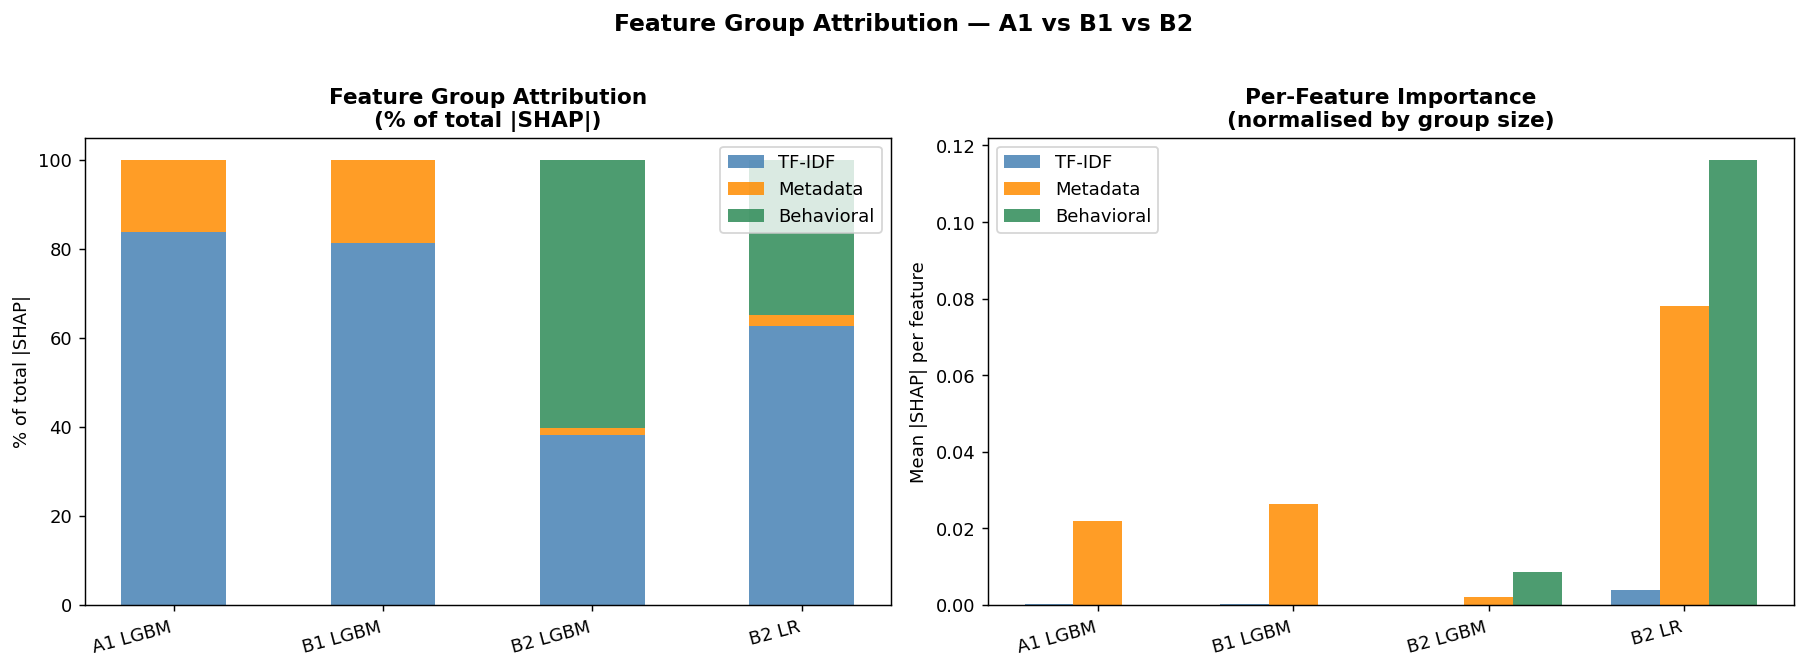

Saved: attribution_comparison.png


In [16]:
print("\n" + "=" * 60)
print("7. FEATURE GROUP ATTRIBUTION")
print("=" * 60)

def group_attribution(mean_abs, n_tfidf, n_meta,
                       n_behav=0, label=""):
    total     = mean_abs.sum()
    tf_sum    = mean_abs[:n_tfidf].sum()
    me_sum    = mean_abs[n_tfidf:n_tfidf+n_meta].sum()
    bh_sum    = mean_abs[n_tfidf+n_meta:].sum() if n_behav > 0 else 0.0
    tf_per    = mean_abs[:n_tfidf].mean()
    me_per    = mean_abs[n_tfidf:n_tfidf+n_meta].mean()
    bh_per    = mean_abs[n_tfidf+n_meta:].mean() if n_behav > 0 else 0.0

    print(f"\n  {label}")
    print(f"  {'Group':12s} {'N':>5} {'Total%':>8} {'Per-feat':>10}")
    print(f"  {'─'*38}")
    print(f"  {'TF-IDF':12s} {n_tfidf:>5} "
          f"{tf_sum/total*100:>7.1f}% {tf_per:>10.6f}")
    print(f"  {'Metadata':12s} {n_meta:>5} "
          f"{me_sum/total*100:>7.1f}% {me_per:>10.6f}")
    if n_behav > 0:
        print(f"  {'Behavioral':12s} {n_behav:>5} "
              f"{bh_sum/total*100:>7.1f}% {bh_per:>10.6f}")

    return dict(
        label=label,
        tfidf_pct=round(tf_sum/total*100, 2),
        meta_pct =round(me_sum/total*100, 2),
        behav_pct=round(bh_sum/total*100, 2),
        tfidf_per=round(tf_per, 6),
        meta_per =round(me_per, 6),
        behav_per=round(bh_per, 6),
    )

attr_a1      = group_attribution(a1_lgbm_mean, a1_N_TFIDF, a1_N_META,
                                  label="A1 LGBM (unfiltered, text+meta)")
attr_b1      = group_attribution(b1_lgbm_mean, b1_N_TFIDF, b1_N_META,
                                  label="B1 LGBM (filtered, text+meta)")
attr_b2_lgbm = group_attribution(b2_lgbm_mean, b2_N_TFIDF, b2_N_META,
                                  b2_N_BEHAV,
                                  label="B2 LGBM (filtered, text+meta+behav)")
attr_b2_lr   = group_attribution(b2_lr_mean,   b2_N_TFIDF, b2_N_META,
                                  b2_N_BEHAV,
                                  label="B2 LR   (filtered, text+meta+behav)")

attr_df = pd.DataFrame([attr_a1, attr_b1, attr_b2_lgbm, attr_b2_lr])
attr_df.to_csv(SHAP_CROSS + "feature_group_attribution.csv", index=False)

# ── Attribution comparison chart ──────────────────────────────
exps       = ["A1 LGBM", "B1 LGBM", "B2 LGBM", "B2 LR"]
tf_pcts    = [a["tfidf_pct"]  for a in [attr_a1, attr_b1,
                                          attr_b2_lgbm, attr_b2_lr]]
me_pcts    = [a["meta_pct"]   for a in [attr_a1, attr_b1,
                                          attr_b2_lgbm, attr_b2_lr]]
bh_pcts    = [a["behav_pct"]  for a in [attr_a1, attr_b1,
                                          attr_b2_lgbm, attr_b2_lr]]
tf_pers    = [a["tfidf_per"]  for a in [attr_a1, attr_b1,
                                          attr_b2_lgbm, attr_b2_lr]]
me_pers    = [a["meta_per"]   for a in [attr_a1, attr_b1,
                                          attr_b2_lgbm, attr_b2_lr]]
bh_pers    = [a["behav_per"]  for a in [attr_a1, attr_b1,
                                          attr_b2_lgbm, attr_b2_lr]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(exps))
w = 0.5

# Left: stacked bar — total %
axes[0].bar(x, tf_pcts, w, label="TF-IDF",
            color="steelblue", alpha=0.85)
axes[0].bar(x, me_pcts, w, bottom=tf_pcts,
            label="Metadata", color="darkorange", alpha=0.85)
axes[0].bar(x, bh_pcts, w,
            bottom=[t+m for t,m in zip(tf_pcts, me_pcts)],
            label="Behavioral", color="seagreen", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(exps, rotation=15, ha="right")
axes[0].set_ylabel("% of total |SHAP|")
axes[0].set_title("Feature Group Attribution\n(% of total |SHAP|)",
                  fontweight="bold")
axes[0].legend()

# Right: grouped bar — per-feature mean |SHAP|
w2 = 0.25
axes[1].bar(x - w2, tf_pers, w2, label="TF-IDF",
            color="steelblue", alpha=0.85)
axes[1].bar(x,       me_pers, w2, label="Metadata",
            color="darkorange", alpha=0.85)
axes[1].bar(x + w2, bh_pers, w2, label="Behavioral",
            color="seagreen", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(exps, rotation=15, ha="right")
axes[1].set_ylabel("Mean |SHAP| per feature")
axes[1].set_title("Per-Feature Importance\n(normalised by group size)",
                  fontweight="bold")
axes[1].legend()

plt.suptitle("Feature Group Attribution — A1 vs B1 vs B2",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(SHAP_CROSS + "attribution_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Saved: attribution_comparison.png")

In [18]:
print("A1 mean SHAP:", a1_lgbm_mean.mean())
print("B1 mean SHAP:", b1_lgbm_mean.mean())
print("B2 mean SHAP:", b2_lgbm_mean.mean())
print("B2 mean SHAP linear:", b2_lr_mean.mean())

A1 mean SHAP: 0.0002725637220215832
B1 mean SHAP: 0.0002828449002713059
B2 mean SHAP: 0.0002576432368011064
B2 mean SHAP linear: 0.0059882605576640074


# ============================================================
# 8. B1 vs B2 INTERPRETABILITY COMPARISON
# ============================================================


8. B1 vs B2 INTERPRETABILITY COMPARISON

Spearman ρ (B1 vs B2 shared features): 0.6102 (p=0.0000)
Top-20 overlap: 9/20 (45%)
Shared: ['came', 'food', 'is', 'pretty', 'service', 'the', 'we', 'review_length', 'review_dayofweek']

Top 10 features that GAINED importance when behavioral features were added:
korean       2192.0
soba         2242.0
and she      2283.0
blocks       2427.0
both were    2441.0
my food      2441.0
not even     2462.0
pudding      2464.0
itself is    2627.0
of you       2719.0

Top 10 features that LOST importance:
in nyc          -2270.0
walk            -2264.0
the red         -2256.0
but they        -2252.0
modern          -2226.0
of an           -2220.0
wait for        -2196.0
with good       -2181.0
meats           -2180.0
delicious the   -2174.0

───────────────────────────────────────────────────────
  INTERPRETATION — Rank Shift B1 → B2
───────────────────────────────────────────────────────

  Features that became LESS important in B2:
    [TF-IDF] in nyc

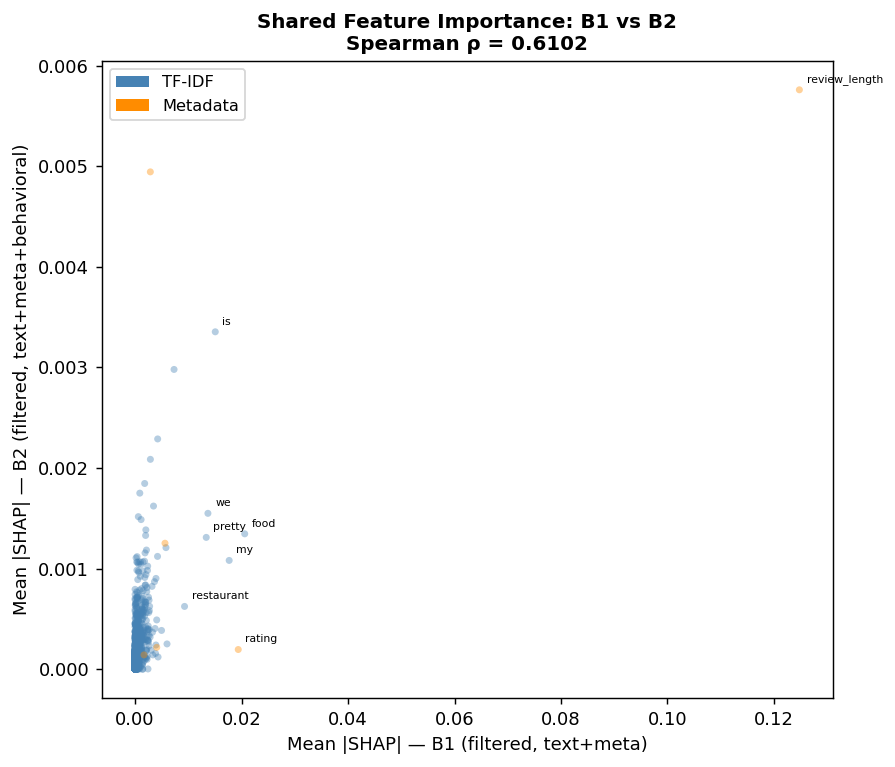


Saved: b1_vs_b2_scatter.png


In [19]:
print("\n" + "=" * 60)
print("8. B1 vs B2 INTERPRETABILITY COMPARISON")
print("=" * 60)

# B1 and B2 share the same TF-IDF vocab and metadata features.
# Directly compare mean |SHAP| on those 3006 shared features.
shared_names = np.array(b1_feature_names)
b1_shared    = b1_lgbm_mean                          # 3006
b2_shared    = b2_lgbm_mean[:b2_N_TFIDF + b2_N_META] # 3006

assert len(b1_shared) == len(b2_shared)

# Spearman rank correlation
rho_b1b2, p_b1b2 = spearmanr(b1_shared, b2_shared)
print(f"\nSpearman ρ (B1 vs B2 shared features): "
      f"{rho_b1b2:.4f} (p={p_b1b2:.4f})")

# Top-20 overlap
N_TOP = 20
b1_top = set(np.argsort(b1_shared)[::-1][:N_TOP])
b2_top = set(np.argsort(b2_shared)[::-1][:N_TOP])
overlap     = b1_top & b2_top
overlap_pct = len(overlap) / N_TOP * 100
print(f"Top-{N_TOP} overlap: {len(overlap)}/{N_TOP} ({overlap_pct:.0f}%)")
if overlap:
    print(f"Shared: {[b1_feature_names[i] for i in sorted(overlap)]}")

# Rank shift
b1_ranks = pd.Series(b1_shared, index=b1_feature_names).rank(
    ascending=False)
b2_ranks = pd.Series(b2_shared, index=b1_feature_names).rank(
    ascending=False)
rank_shift = (b2_ranks - b1_ranks).sort_values()

print(f"\nTop 10 features that GAINED importance when "
      f"behavioral features were added:")
print(rank_shift.tail(10).to_string())
print(f"\nTop 10 features that LOST importance:")
print(rank_shift.head(10).to_string())

rank_shift.to_csv(SHAP_CROSS + "b1_vs_b2_rank_shift.csv",
                  header=["rank_change"])

# ── Plain-English interpretation of rank shift ────────────────
print("\n" + "─" * 55)
print("  INTERPRETATION — Rank Shift B1 → B2")
print("─" * 55)

# Features that lost rank are likely being "replaced" by
# behavioral features. Features that gained rank are those
# that behavioral features could not capture.
top_losers  = rank_shift.head(5).index.tolist()
top_gainers = rank_shift.tail(5).index.tolist()

loser_types  = ["TF-IDF" if b1_feature_names.index(f) < b1_N_TFIDF
                else "Metadata" for f in top_losers]
gainer_types = ["TF-IDF" if b1_feature_names.index(f) < b1_N_TFIDF
                else "Metadata" for f in top_gainers]

print(f"\n  Features that became LESS important in B2:")
for f, t in zip(top_losers, loser_types):
    print(f"    [{t}] {f}")
print(f"\n  Features that became MORE important in B2:")
for f, t in zip(top_gainers, gainer_types):
    print(f"    [{t}] {f}")

if rho_b1b2 > 0.7:
    shift_conclusion = (
        "HIGH agreement (ρ={:.3f}) — behavioral features did NOT "
        "dramatically change model reliance on text/metadata. "
        "Behavioral features added new signals on top of existing ones."
    ).format(rho_b1b2)
elif rho_b1b2 > 0.4:
    shift_conclusion = (
        "MODERATE agreement (ρ={:.3f}) — behavioral features "
        "partially redistributed importance away from text/metadata."
    ).format(rho_b1b2)
else:
    shift_conclusion = (
        "LOW agreement (ρ={:.3f}) — behavioral features substantially "
        "changed what drives detection. Text features became much less "
        "important relative to behavioral signals."
    ).format(rho_b1b2)

print(f"\n  Conclusion: {shift_conclusion}")

# Scatter: B1 vs B2 shared feature importance
fig, ax = plt.subplots(figsize=(7, 6))
colours = (["steelblue"] * b1_N_TFIDF + ["darkorange"] * b1_N_META)
ax.scatter(b1_shared, b2_shared, c=colours,
           alpha=0.4, s=15, linewidths=0)
top_shift = np.argsort(np.abs(b2_shared - b1_shared))[::-1][:8]
for i in top_shift:
    ax.annotate(shared_names[i],
                (b1_shared[i], b2_shared[i]),
                fontsize=6, xytext=(4, 4),
                textcoords="offset points")
ax.set_xlabel("Mean |SHAP| — B1 (filtered, text+meta)")
ax.set_ylabel("Mean |SHAP| — B2 (filtered, text+meta+behavioral)")
ax.set_title(f"Shared Feature Importance: B1 vs B2\n"
             f"Spearman ρ = {rho_b1b2:.4f}",
             fontsize=11, fontweight="bold")
ax.legend(handles=[
    Patch(facecolor="steelblue",  label="TF-IDF"),
    Patch(facecolor="darkorange", label="Metadata"),
], fontsize=9)
plt.tight_layout()
plt.savefig(SHAP_CROSS + "b1_vs_b2_scatter.png",
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("\nSaved: b1_vs_b2_scatter.png")

# ============================================================
# 9. SHAP SUMMARY AND BAR PLOTS
# ============================================================


9. SHAP SUMMARY AND BAR PLOTS


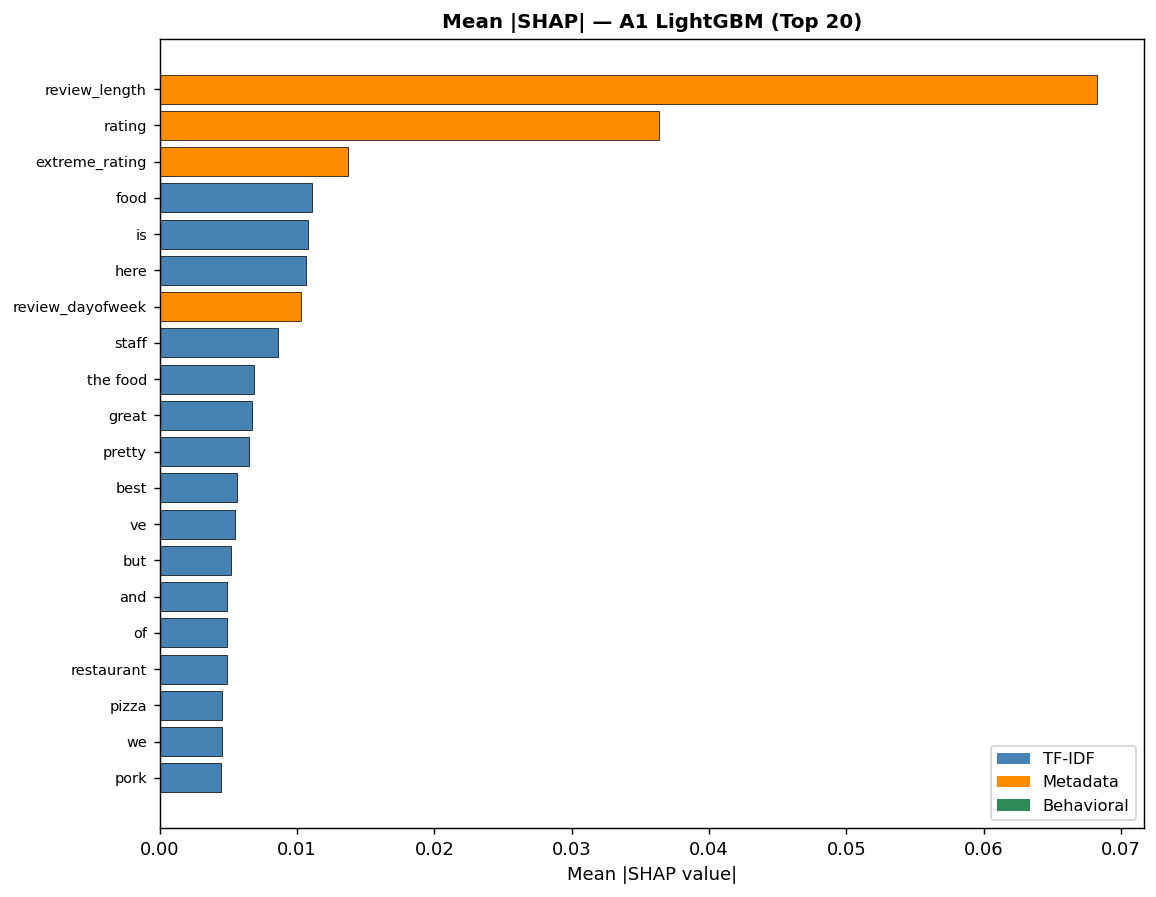

Saved: shap_bar_a1.png


/tmp/ipykernel_858/2747491947.py:39: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


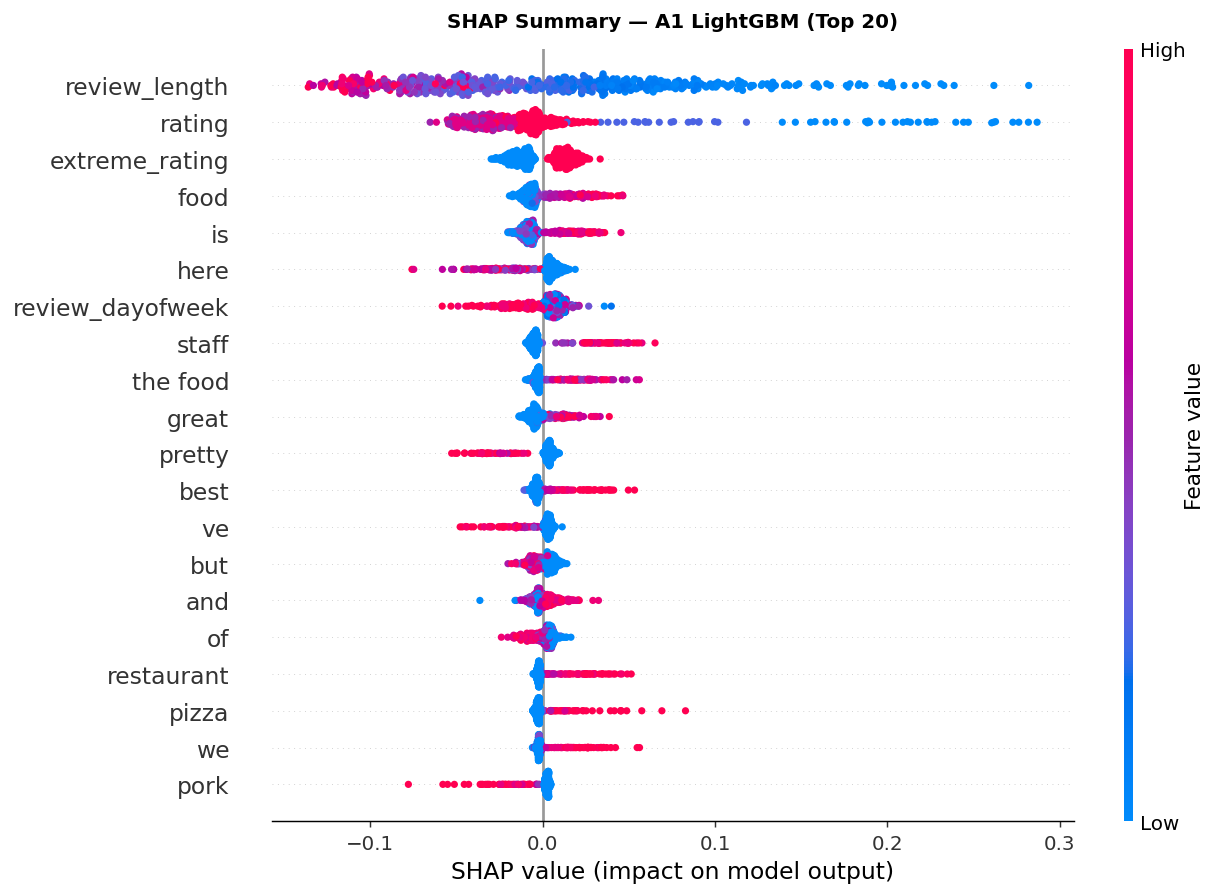

Saved: shap_summary_a1.png


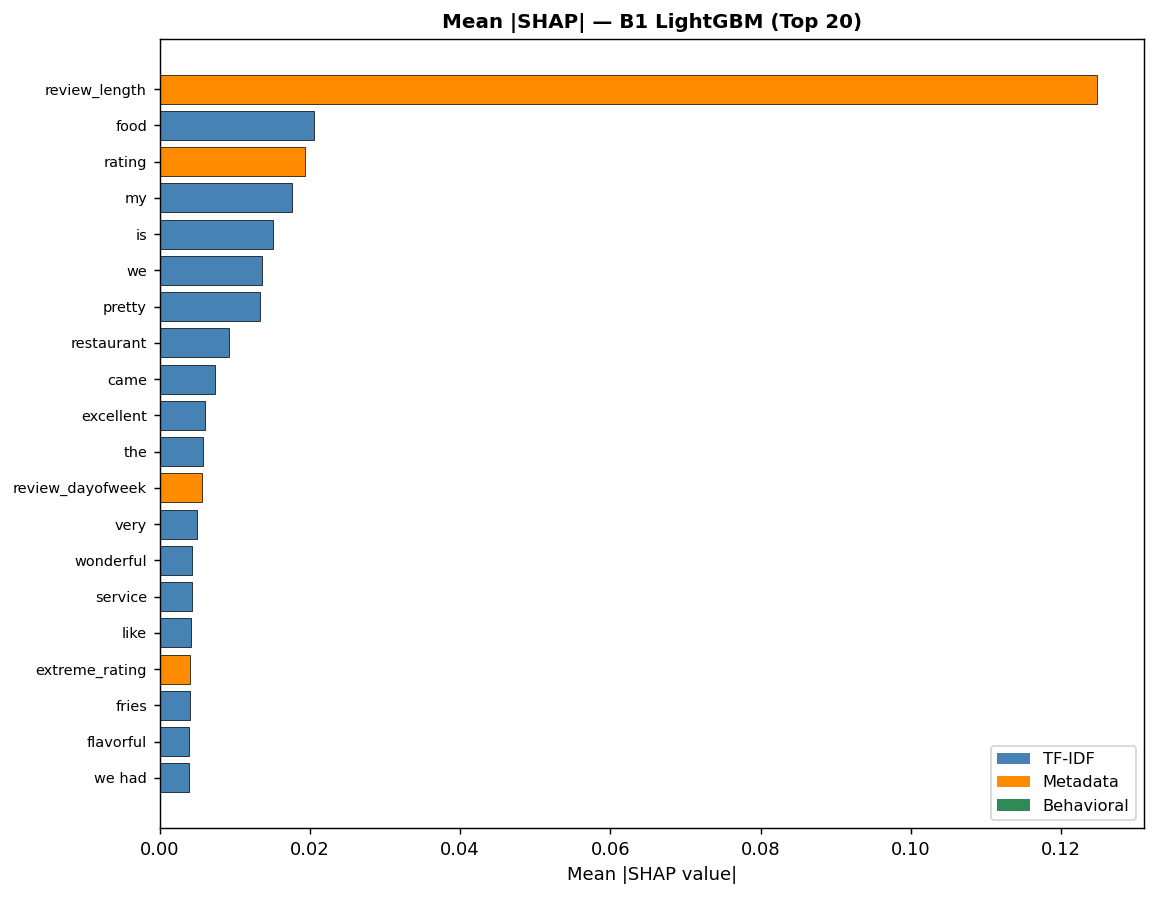

Saved: shap_bar_b1.png


/tmp/ipykernel_858/2747491947.py:39: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


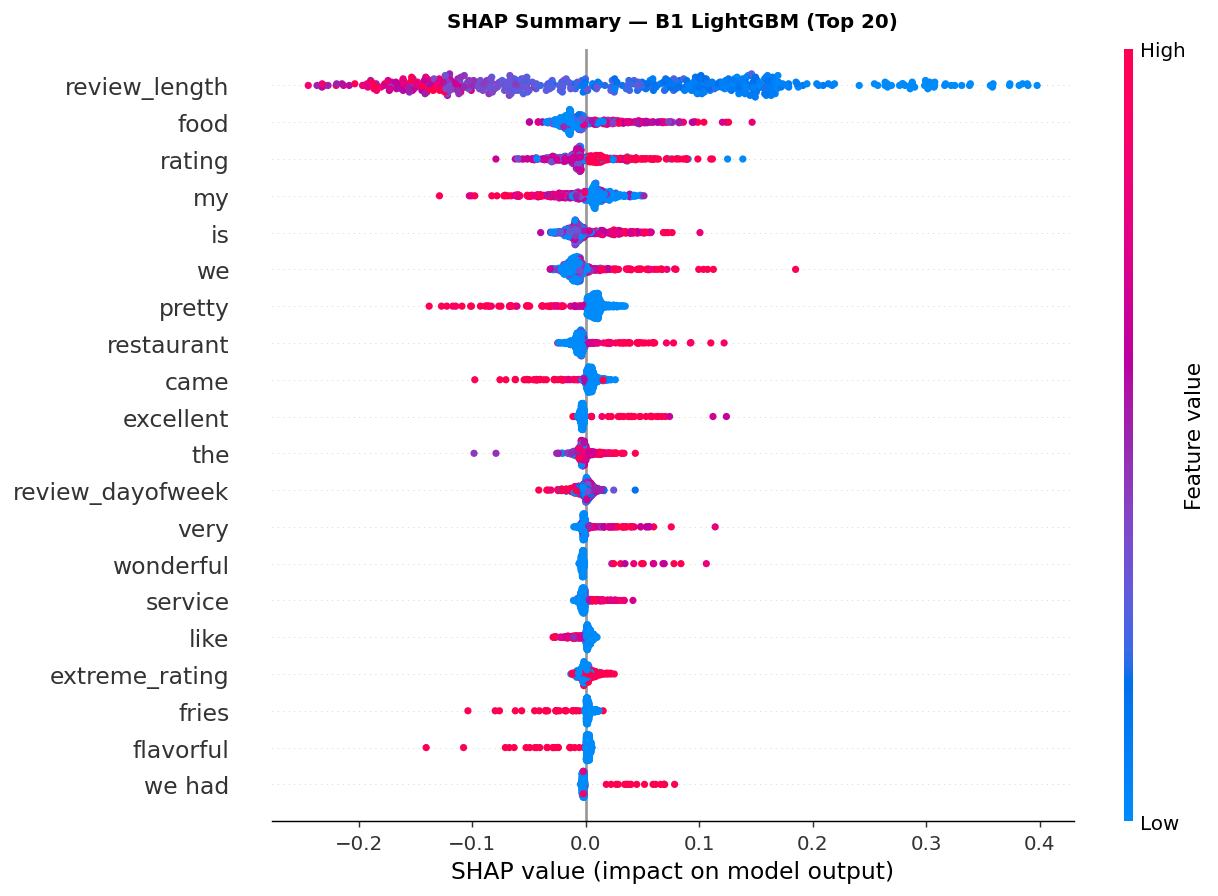

Saved: shap_summary_b1.png


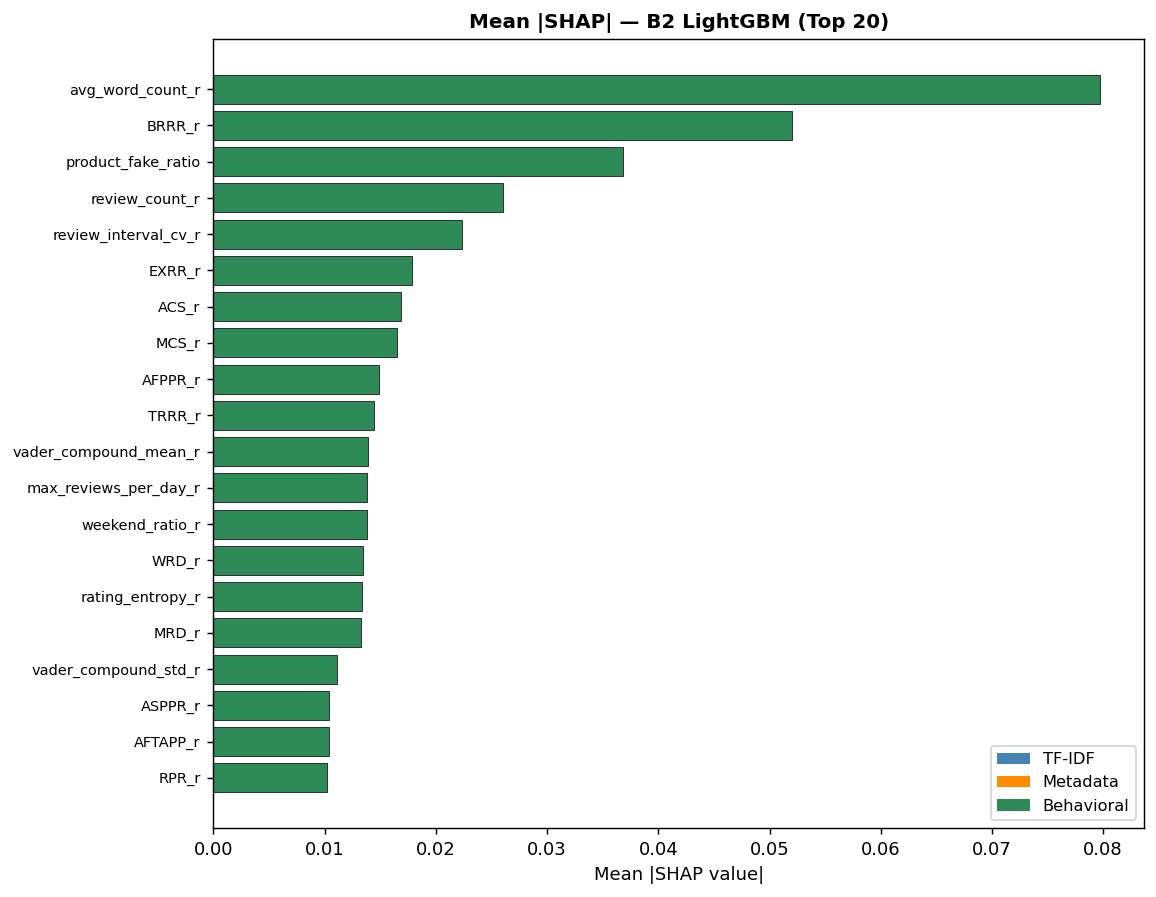

Saved: shap_bar_b2_lgbm.png


/tmp/ipykernel_858/2747491947.py:39: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


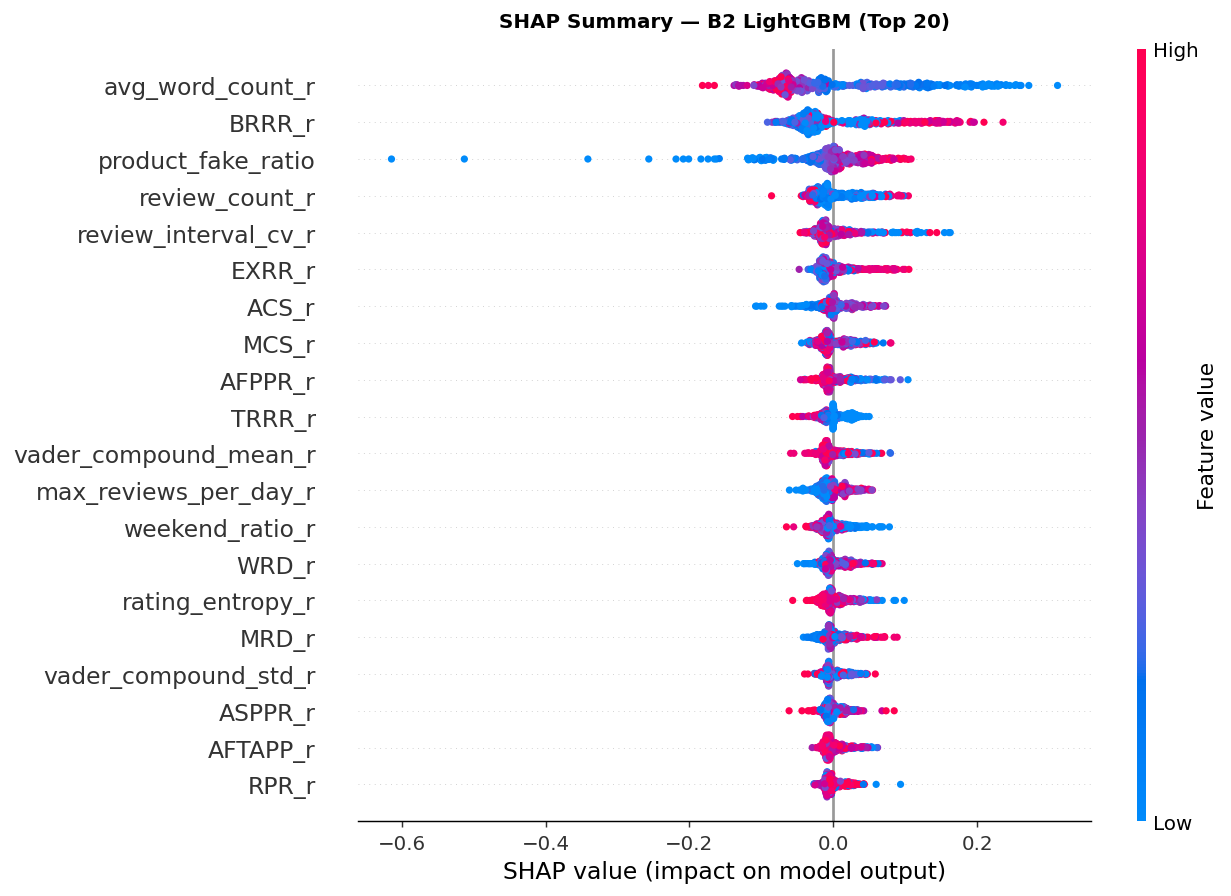

Saved: shap_summary_b2_lgbm.png


/tmp/ipykernel_858/2747491947.py:39: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


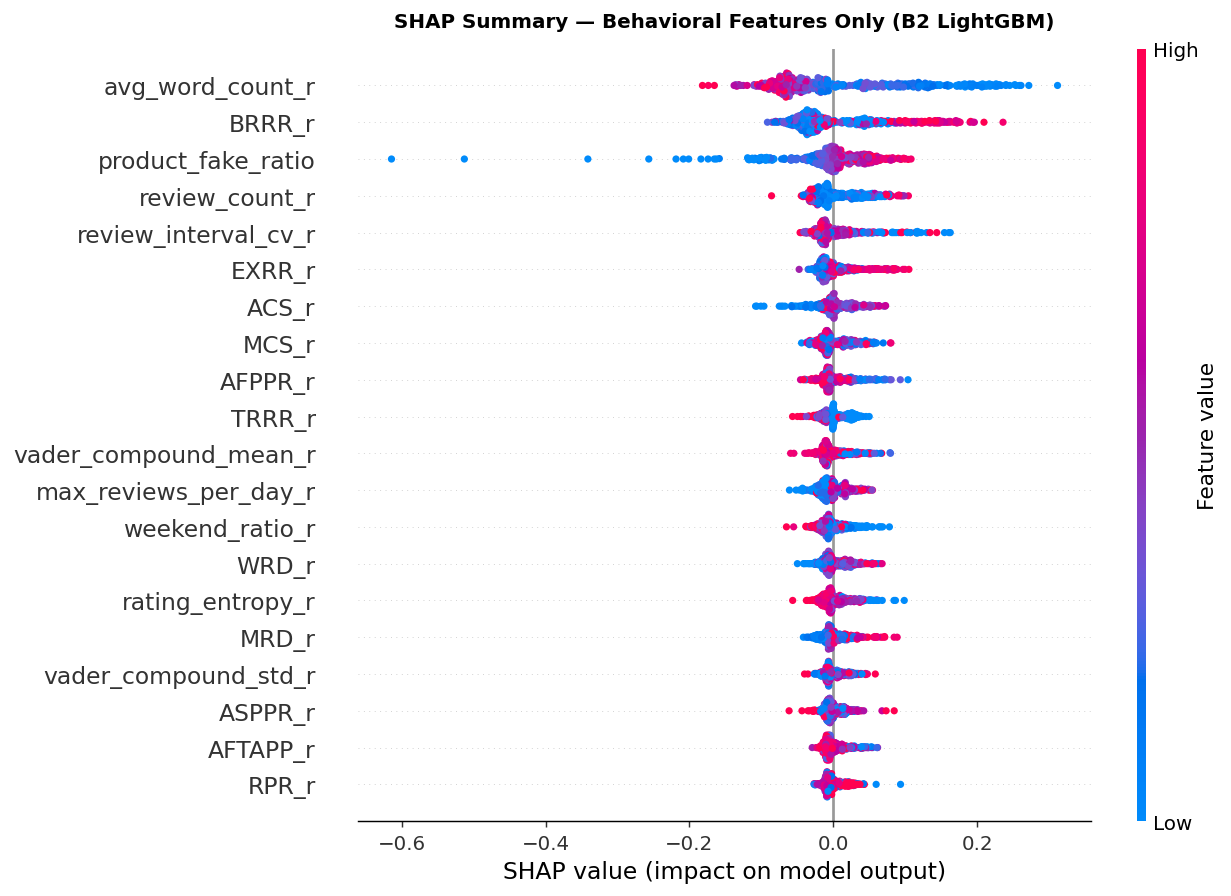

Saved: shap_summary_b2_behavioral_only.png


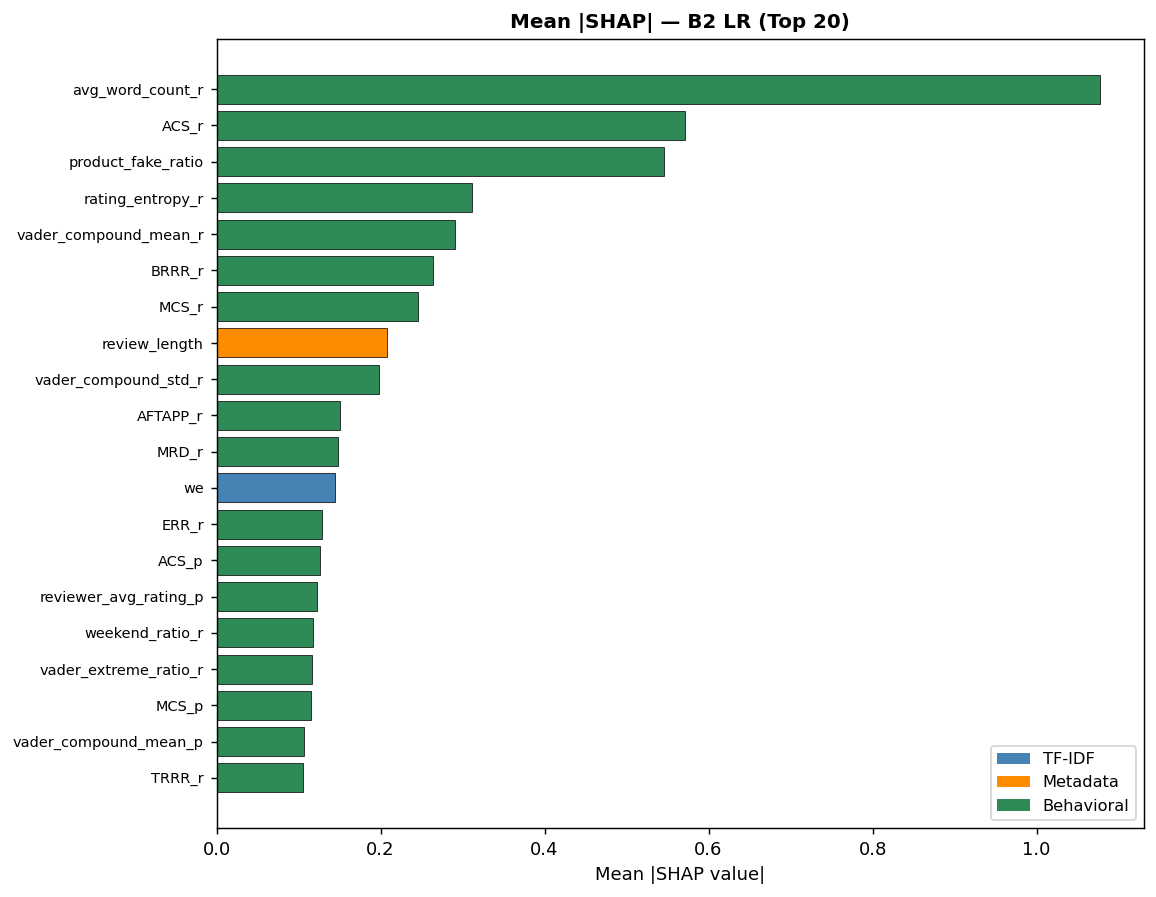

Saved: shap_bar_b2_lr.png


In [20]:
print("\n" + "=" * 60)
print("9. SHAP SUMMARY AND BAR PLOTS")
print("=" * 60)

def shap_bar(mean_abs, feature_names_arr, n_tfidf, n_meta,
             title, filepath, n=20):
    top_idx   = np.argsort(mean_abs)[::-1][:n]
    top_vals  = mean_abs[top_idx][::-1]
    top_names = feature_names_arr[top_idx][::-1]
    colours   = []
    for idx in top_idx[::-1]:
        if idx < n_tfidf:
            colours.append("steelblue")
        elif idx < n_tfidf + n_meta:
            colours.append("darkorange")
        else:
            colours.append("seagreen")
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(range(n), top_vals, color=colours,
            edgecolor="black", linewidth=0.4)
    ax.set_yticks(range(n))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(handles=[
        Patch(facecolor="steelblue",  label="TF-IDF"),
        Patch(facecolor="darkorange", label="Metadata"),
        Patch(facecolor="seagreen",   label="Behavioral"),
    ], loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {os.path.basename(filepath)}")

def shap_summary(shap_vals, X_dense, feature_names_arr,
                  mean_abs, title, filepath, n=20):
    top_idx = np.argsort(mean_abs)[::-1][:n]
    shap.summary_plot(
        shap_vals[:, top_idx],
        X_dense[:, top_idx],
        feature_names=feature_names_arr[top_idx],
        show=False, plot_size=(10, 7)
    )
    plt.title(title, fontsize=11, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {os.path.basename(filepath)}")

fn_a1 = np.array(a1_feature_names)
fn_b1 = np.array(b1_feature_names)
fn_b2 = np.array(b2_feature_names)

# A1
shap_bar(a1_lgbm_mean, fn_a1, a1_N_TFIDF, a1_N_META,
         "Mean |SHAP| — A1 LightGBM (Top 20)",
         SHAP_A1 + "shap_bar_a1.png")
shap_summary(a1_lgbm_shap, X_a1_shap, fn_a1, a1_lgbm_mean,
             "SHAP Summary — A1 LightGBM (Top 20)",
             SHAP_A1 + "shap_summary_a1.png")

# B1
shap_bar(b1_lgbm_mean, fn_b1, b1_N_TFIDF, b1_N_META,
         "Mean |SHAP| — B1 LightGBM (Top 20)",
         SHAP_B1 + "shap_bar_b1.png")
shap_summary(b1_lgbm_shap, X_b1_shap, fn_b1, b1_lgbm_mean,
             "SHAP Summary — B1 LightGBM (Top 20)",
             SHAP_B1 + "shap_summary_b1.png")

# B2 LightGBM — all features top 20
shap_bar(b2_lgbm_mean, fn_b2, b2_N_TFIDF, b2_N_META,
         "Mean |SHAP| — B2 LightGBM (Top 20)",
         SHAP_B2 + "shap_bar_b2_lgbm.png")
shap_summary(b2_lgbm_shap, X_b2_shap, fn_b2, b2_lgbm_mean,
             "SHAP Summary — B2 LightGBM (Top 20)",
             SHAP_B2 + "shap_summary_b2_lgbm.png")

# B2 LightGBM — BEHAVIORAL ONLY beeswarm
# Separate plot so behavioral features are not buried by TF-IDF
behav_arr  = np.array(behav_cols)
lgbm_bh_abs = b2_lgbm_mean[behav_start:]
lr_bh_abs   = b2_lr_mean[behav_start:]

shap_summary(
    b2_lgbm_shap[:, behav_start:],
    X_b2_shap[:, behav_start:],
    behav_arr,
    lgbm_bh_abs,
    "SHAP Summary — Behavioral Features Only (B2 LightGBM)",
    SHAP_B2 + "shap_summary_b2_behavioral_only.png",
    n=min(20, b2_N_BEHAV)
)

# B2 LR — bar
shap_bar(b2_lr_mean, fn_b2, b2_N_TFIDF, b2_N_META,
         "Mean |SHAP| — B2 LR (Top 20)",
         SHAP_B2 + "shap_bar_b2_lr.png")


# ============================================================
# 10. BEHAVIORAL FEATURE RANKING (B2)
# ============================================================


10. BEHAVIORAL FEATURE RANKING — B2

Behavioral features ranked by B2 LightGBM SHAP:
                     feature  lgbm_mean_shap  lr_mean_shap
            avg_word_count_r        0.079687      1.077125
                      BRRR_r        0.052026      0.264434
          product_fake_ratio        0.036808      0.546068
              review_count_r        0.026010      0.098031
        review_interval_cv_r        0.022355      0.048221
                      EXRR_r        0.017870      0.031337
                       ACS_r        0.016891      0.570977
                       MCS_r        0.016488      0.245709
                     AFPPR_r        0.014857      0.061334
                      TRRR_r        0.014449      0.105273
       vader_compound_mean_r        0.013864      0.290300
       max_reviews_per_day_r        0.013814      0.092077
             weekend_ratio_r        0.013807      0.117682
                       WRD_r        0.013467      0.092769
            rating_entropy_r 

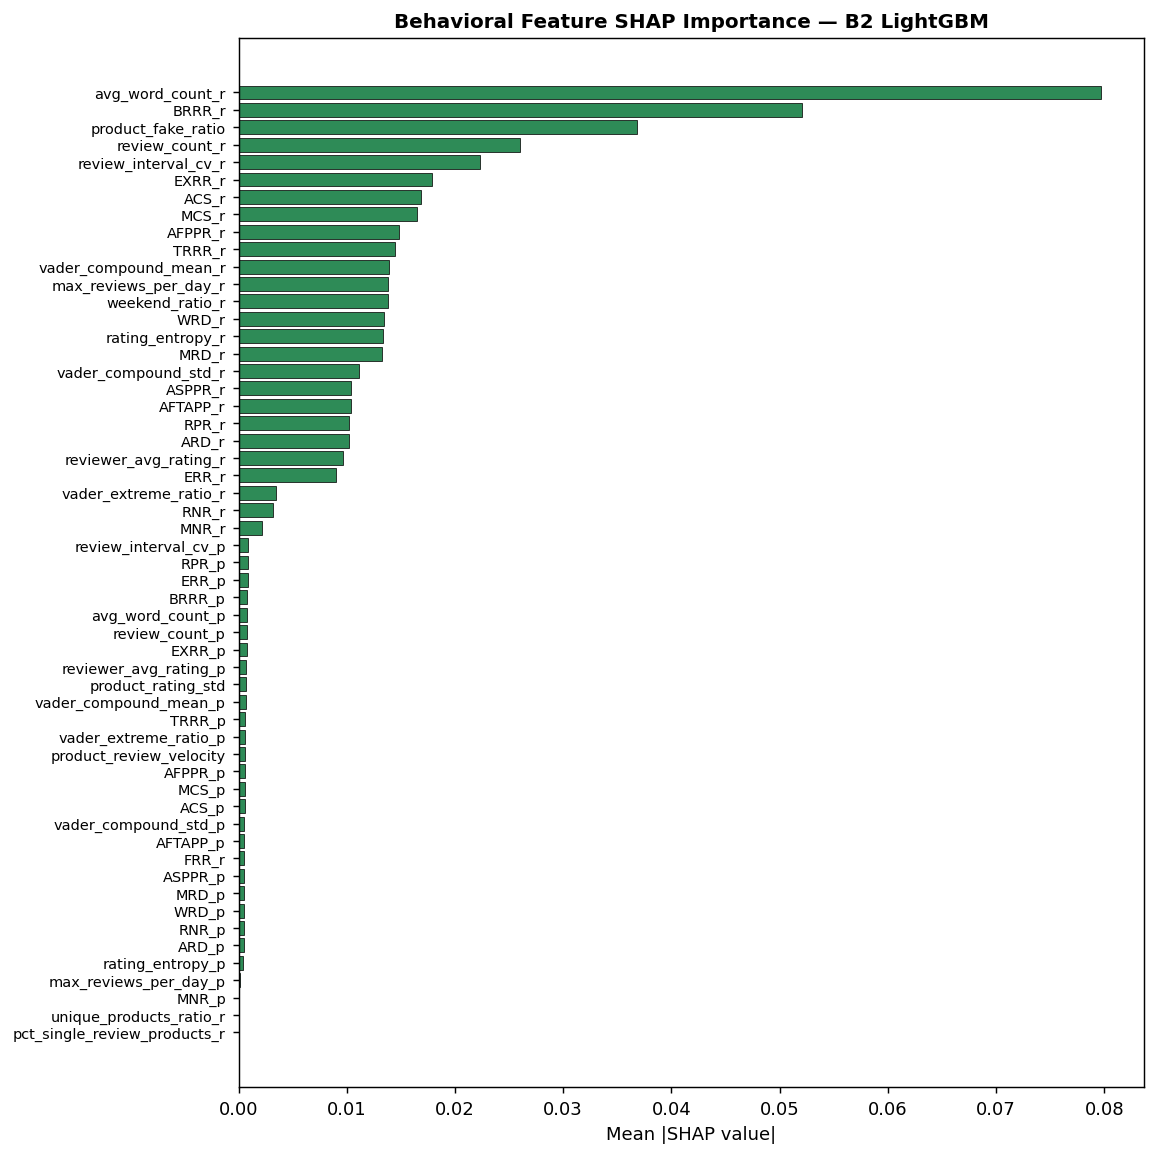

Saved: shap_behavioral_ranking.png


In [21]:
print("\n" + "=" * 60)
print("10. BEHAVIORAL FEATURE RANKING — B2")
print("=" * 60)

behav_rank_df = pd.DataFrame({
    "feature":         behav_arr,
    "lgbm_mean_shap":  lgbm_bh_abs,
    "lr_mean_shap":    lr_bh_abs,
}).sort_values("lgbm_mean_shap", ascending=False).reset_index(drop=True)

print("\nBehavioral features ranked by B2 LightGBM SHAP:")
print(behav_rank_df.to_string(index=False))
behav_rank_df.to_csv(SHAP_B2 + "behavioral_ranking.csv", index=False)

# Full ranking bar chart
sorted_idx   = np.argsort(lgbm_bh_abs)
fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(range(b2_N_BEHAV),
        lgbm_bh_abs[sorted_idx],
        color="seagreen", edgecolor="black", linewidth=0.4)
ax.set_yticks(range(b2_N_BEHAV))
ax.set_yticklabels(behav_arr[sorted_idx], fontsize=8)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Behavioral Feature SHAP Importance — B2 LightGBM",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(SHAP_B2 + "shap_behavioral_ranking.png",
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Saved: shap_behavioral_ranking.png")

# ============================================================
# 11. CROSS-MODEL STABILITY — B2 (LR vs LightGBM)
# ============================================================


11. CROSS-MODEL SHAP STABILITY — B2
  All features                       : ρ = 0.6123  (p=0.0000)
  Behavioral only                    : ρ = 0.5591  (p=0.0000)
  Metadata only                      : ρ = 0.0286  (p=0.9572)
  TF-IDF top 100                     : ρ = 0.3802  (p=0.0001)

Saved: shap_stability.csv


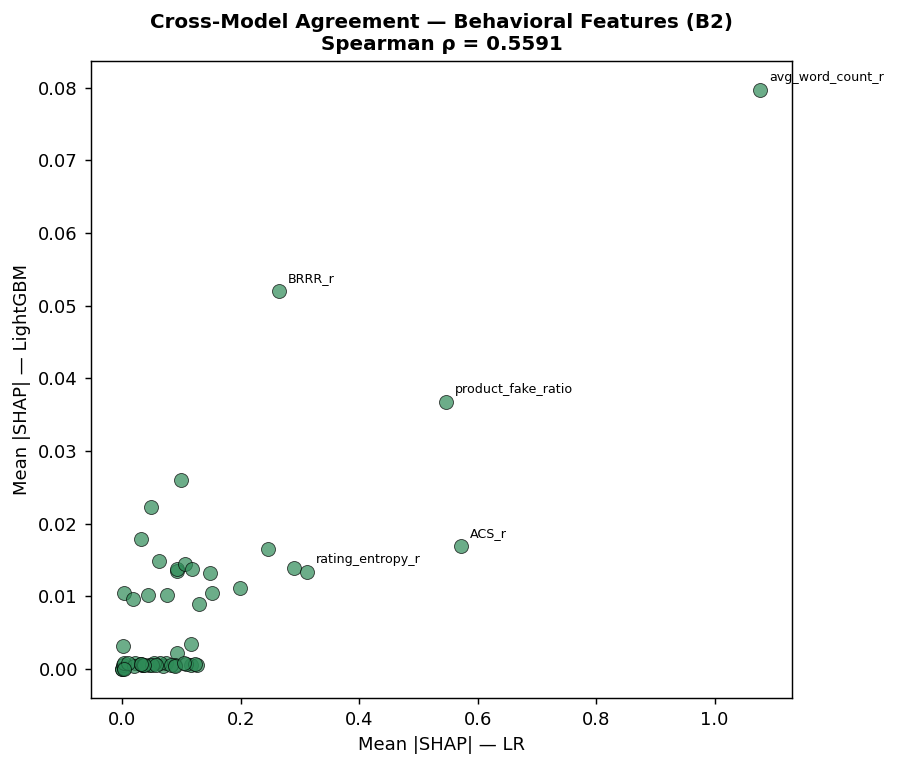

Saved: shap_stability_scatter.png


In [22]:
print("\n" + "=" * 60)
print("11. CROSS-MODEL SHAP STABILITY — B2")
print("=" * 60)

def spearman_row(a, b, group):
    rho, p = spearmanr(a, b)
    print(f"  {group:35s}: ρ = {rho:.4f}  (p={p:.4f})")
    return {"group": group, "rho": round(rho, 4), "p": round(p, 4)}

rows = []
rows.append(spearman_row(b2_lr_mean, b2_lgbm_mean, "All features"))
rows.append(spearman_row(lr_bh_abs,  lgbm_bh_abs,  "Behavioral only"))
rows.append(spearman_row(
    b2_lr_mean[b2_N_TFIDF:b2_N_TFIDF+b2_N_META],
    b2_lgbm_mean[b2_N_TFIDF:b2_N_TFIDF+b2_N_META],
    "Metadata only"
))
top100 = np.argsort(b2_lr_mean[:b2_N_TFIDF] +
                    b2_lgbm_mean[:b2_N_TFIDF])[::-1][:100]
rows.append(spearman_row(b2_lr_mean[top100],
                          b2_lgbm_mean[top100], "TF-IDF top 100"))

stab_df = pd.DataFrame(rows)
stab_df.to_csv(SHAP_B2 + "shap_stability.csv", index=False)
print("\nSaved: shap_stability.csv")

rho_behav_xm = stab_df.loc[
    stab_df["group"] == "Behavioral only", "rho"].values[0]

# Scatter
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(lr_bh_abs, lgbm_bh_abs, color="seagreen",
           alpha=0.7, edgecolors="black", linewidth=0.5, s=60)
top5 = np.argsort(lr_bh_abs + lgbm_bh_abs)[::-1][:5]
for i in top5:
    ax.annotate(behav_cols[i], (lr_bh_abs[i], lgbm_bh_abs[i]),
                fontsize=7, xytext=(5, 5),
                textcoords="offset points")
ax.set_xlabel("Mean |SHAP| — LR")
ax.set_ylabel("Mean |SHAP| — LightGBM")
ax.set_title(
    f"Cross-Model Agreement — Behavioral Features (B2)\n"
    f"Spearman ρ = {rho_behav_xm:.4f}",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig(SHAP_B2 + "shap_stability_scatter.png",
            dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Saved: shap_stability_scatter.png")

# ============================================================
# 12. SHAP DEPENDENCE PLOTS — TOP 5 BEHAVIORAL (B2 LGBM)
# ============================================================


12. SHAP DEPENDENCE PLOTS — TOP 5 BEHAVIORAL


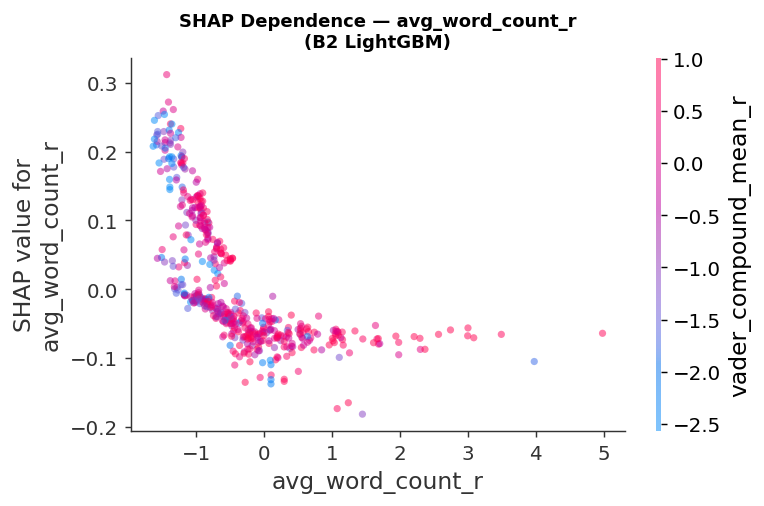

Saved: shap_dependence_avg_word_count_r.png


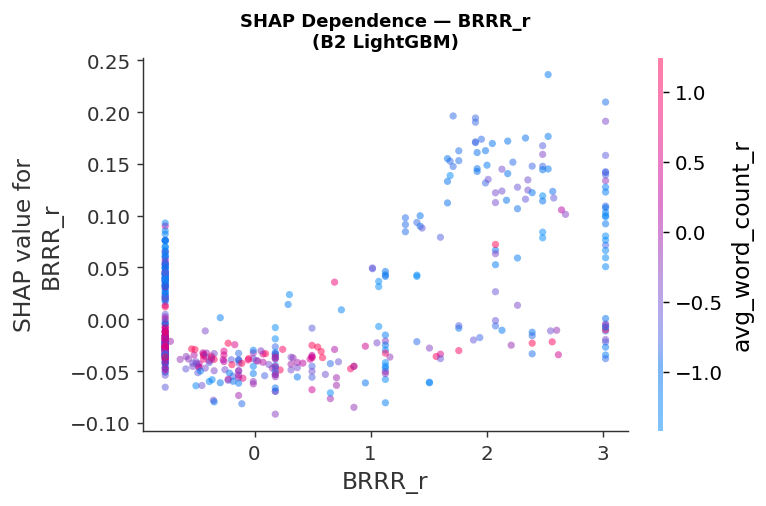

Saved: shap_dependence_BRRR_r.png


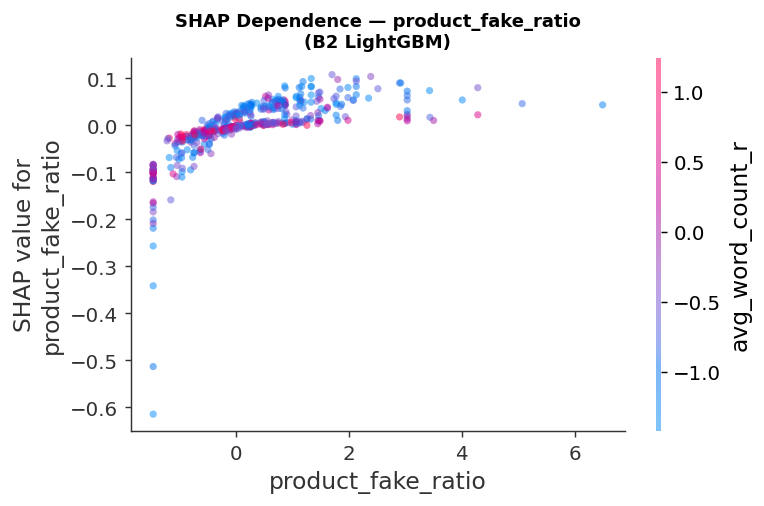

Saved: shap_dependence_product_fake_ratio.png


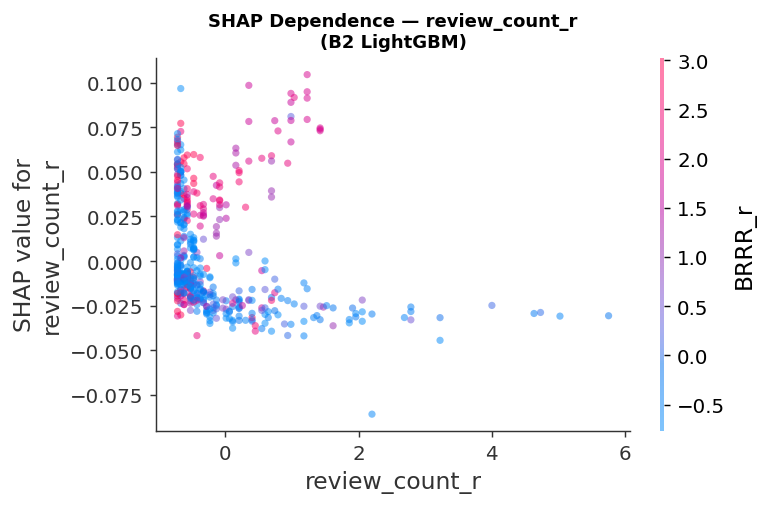

Saved: shap_dependence_review_count_r.png


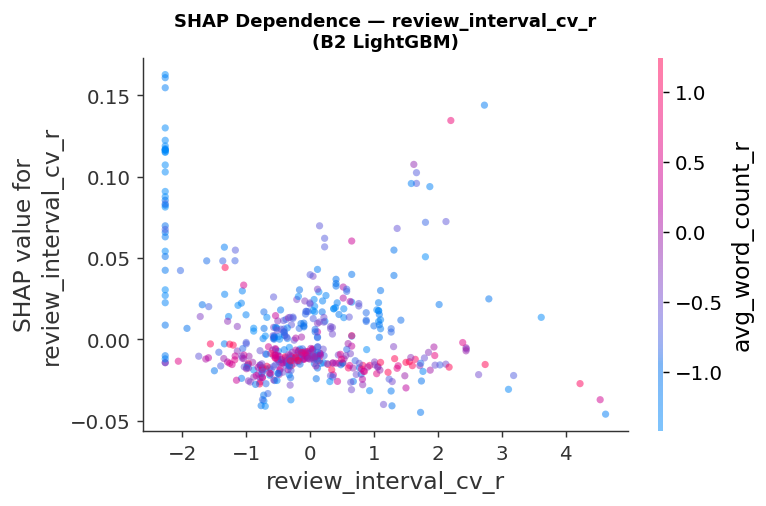

Saved: shap_dependence_review_interval_cv_r.png


In [23]:
print("\n" + "=" * 60)
print("12. SHAP DEPENDENCE PLOTS — TOP 5 BEHAVIORAL")
print("=" * 60)

top5_idx   = np.argsort(lgbm_bh_abs)[::-1][:5]
top5_names = [behav_cols[i] for i in top5_idx]
top5_gidx  = [behav_start + i for i in top5_idx]

for name, g_idx in zip(top5_names, top5_gidx):
    fig, ax = plt.subplots(figsize=(6, 4))
    shap.dependence_plot(
        g_idx, b2_lgbm_shap, X_b2_shap,
        feature_names=b2_feature_names,
        ax=ax, show=False, alpha=0.5
    )
    ax.set_title(f"SHAP Dependence — {name}\n(B2 LightGBM)",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    safe = name.replace("/", "_").replace(" ", "_")
    plt.savefig(SHAP_B2 + f"shap_dependence_{safe}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: shap_dependence_{safe}.png")


# ============================================================
# 13. KEY FINDINGS — LINKED TO RESEARCH QUESTION
# ============================================================

In [24]:
print("\n" + "=" * 60)
print("13. KEY FINDINGS — RESEARCH QUESTION ANSWERED")
print("=" * 60)

top_behav_name = behav_rank_df["feature"].iloc[0]
top_behav_shap = behav_rank_df["lgbm_mean_shap"].iloc[0]

print(f"""
Research question:
  "Does filtering + behavioral features change what drives
   fake review detection?"

─────────────────────────────────────────────────────────────

1. FEATURE GROUP ATTRIBUTION (B2 LightGBM)
   TF-IDF     : {attr_b2_lgbm['tfidf_pct']:.1f}% of total |SHAP|
                ({attr_b2_lgbm['tfidf_per']:.6f} per feature)
   Metadata   : {attr_b2_lgbm['meta_pct']:.1f}%
                ({attr_b2_lgbm['meta_per']:.6f} per feature)
   Behavioral : {attr_b2_lgbm['behav_pct']:.1f}%
                ({attr_b2_lgbm['behav_per']:.6f} per feature)

   → Per-feature, behavioral signals are
     {'STRONGER' if attr_b2_lgbm['behav_per'] > attr_b2_lgbm['tfidf_per']
      else 'WEAKER'} than TF-IDF and
     {'STRONGER' if attr_b2_lgbm['behav_per'] > attr_b2_lgbm['meta_per']
      else 'WEAKER'} than metadata.

2. B1 vs B2 SHARED FEATURE SHIFT
   Spearman ρ on shared features: {rho_b1b2:.4f}
   Top-20 overlap: {len(overlap)}/{N_TOP} ({overlap_pct:.0f}%)

   → {shift_conclusion}

3. MOST IMPORTANT BEHAVIORAL FEATURE (B2 LightGBM)
   '{top_behav_name}' (mean |SHAP| = {top_behav_shap:.6f})

4. CROSS-MODEL STABILITY (LR vs LightGBM within B2)
   Behavioral features Spearman ρ: {rho_behav_xm:.4f}
   → {'High' if rho_behav_xm > 0.7 else 'Moderate' if rho_behav_xm > 0.4 else 'Low'}
     cross-model agreement on behavioral feature importance.

─────────────────────────────────────────────────────────────
OVERALL CONCLUSION:
Filtering restricts the dataset to reviewers with sufficient
history to compute behavioral features. These features
{'introduce substantial new predictive signals beyond text'
 if attr_b2_lgbm['behav_per'] > attr_b2_lgbm['tfidf_per']
 else 'complement but do not fully replace text-based signals'}.
The shift in shared feature ranks (ρ={rho_b1b2:.3f}) indicates
{'a meaningful change' if rho_b1b2 < 0.7 else 'relative stability'}
in model reasoning when behavioral features are added.
─────────────────────────────────────────────────────────────
""")

# Save findings
findings = {
    "b2_lgbm_tfidf_pct":   attr_b2_lgbm["tfidf_pct"],
    "b2_lgbm_meta_pct":    attr_b2_lgbm["meta_pct"],
    "b2_lgbm_behav_pct":   attr_b2_lgbm["behav_pct"],
    "b2_lgbm_tfidf_per":   attr_b2_lgbm["tfidf_per"],
    "b2_lgbm_behav_per":   attr_b2_lgbm["behav_per"],
    "b1_b2_spearman_rho":  round(rho_b1b2, 4),
    "top20_overlap_pct":   round(overlap_pct, 1),
    "top_behav_feature":   top_behav_name,
    "xmodel_behav_rho":    rho_behav_xm,
}
pd.Series(findings).to_csv(SHAP_CROSS + "key_findings.csv",
                            header=["value"])
print("Saved: key_findings.csv")

print("\n" + "=" * 60)
print("SHAP ANALYSIS COMPLETE")
print("=" * 60)
print(f"""
All outputs saved to:
  {SHAP_A1}    — A1 plots
  {SHAP_B1}    — B1 plots
  {SHAP_B2}    — B2 plots + stability + dependence + behavioral ranking
  {SHAP_CROSS} — cross-experiment comparison
""")



13. KEY FINDINGS — RESEARCH QUESTION ANSWERED

Research question:
  "Does filtering + behavioral features change what drives
   fake review detection?"
 
─────────────────────────────────────────────────────────────
 
1. FEATURE GROUP ATTRIBUTION (B2 LightGBM)
   TF-IDF     : 38.2% of total |SHAP|
                (0.000100 per feature)
   Metadata   : 1.6%
                (0.002085 per feature)
   Behavioral : 60.2%
                (0.008637 per feature)
 
   → Per-feature, behavioral signals are
     STRONGER than TF-IDF and
     STRONGER than metadata.
 
2. B1 vs B2 SHARED FEATURE SHIFT
   Spearman ρ on shared features: 0.6102
   Top-20 overlap: 9/20 (45%)
 
   → MODERATE agreement (ρ=0.610) — behavioral features partially redistributed importance away from text/metadata.
 
3. MOST IMPORTANT BEHAVIORAL FEATURE (B2 LightGBM)
   'avg_word_count_r' (mean |SHAP| = 0.079687)
 
4. CROSS-MODEL STABILITY (LR vs LightGBM within B2)
   Behavioral features Spearman ρ: 0.5591
   → Moderate
    